In [30]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [14]:
df1 = pd.read_csv("../data/airline_passengers.csv", index_col="Month", parse_dates=True)
df1.index.freq = "MS"

df2 = pd.read_csv("../data/DailyTotalFemaleBirths.csv", index_col="Date", parse_dates=True)
df2.index.freq = "D"

df3 = pd.read_csv("../data/TradeInventories.csv", index_col="Date", parse_dates=True)
df3.index.freq = "MS"

In [7]:
# the auto_arima function is a convenient way to find the best ARIMA model for a given time series,
# trace parameter is set to True to print the results of the model selection process

# it wont check all the combinations of p and q, but it will check a subset of them, 
# based on the AIC criterion
stepwise_fit = auto_arima(df2["Births"], start_p=0, start_q=0, max_p=6, max_q=3, seasonal=False, trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2650.760, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2565.234, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2463.584, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2648.768, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2460.154, Time=0.21 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2461.271, Time=0.34 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2460.722, Time=0.24 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2536.154, Time=0.15 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2463.038, Time=0.97 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2459.074, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2462.221, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2563.261, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=2460.367, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0]             : 

In [8]:
print(stepwise_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1226.537
Date:                Wed, 18 Feb 2026   AIC                           2459.074
Time:                        17:58:36   BIC                           2470.766
Sample:                    01-01-1959   HQIC                          2463.721
                         - 12-31-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1252      0.060      2.097      0.036       0.008       0.242
ma.L1         -0.9624      0.017    -56.429      0.000      -0.996      -0.929
sigma2        49.1512      3.250     15.122      0.0

In [11]:
# m=12 since we are working with monthly data, and we want to check for seasonality in the data
stepwise_fit = auto_arima(df1["Thousands of Passengers"], start_p=0, start_q=0, max_p=4, max_q=4, seasonal=True, trace=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1032.128, Time=0.40 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.20 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.45 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.29 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.41 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.22 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.43 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.65 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.36 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.18 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.69 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [12]:
print(stepwise_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Wed, 18 Feb 2026   AIC                           1019.178
Time:                                     18:03:07   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      

## ARMA

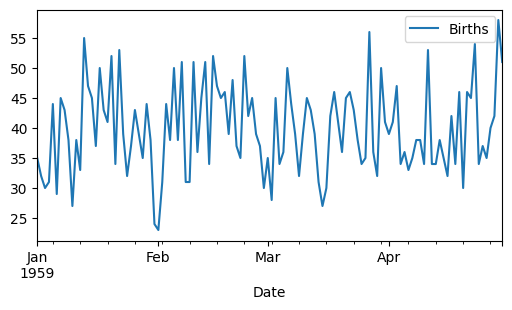

In [19]:
df2 = df2[:120] # grab just the first 10 years of data, to make sure it is stationary, just for this example
df2.plot(figsize=(6, 3));

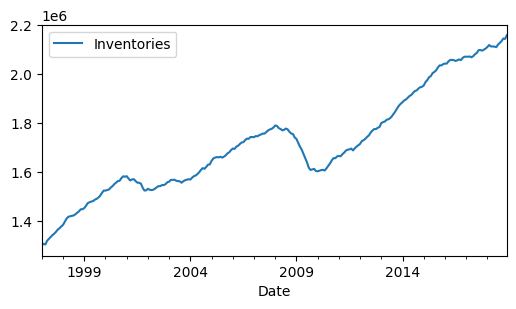

In [20]:
df3.plot(figsize=(6, 3));

In [22]:
# from previous examples
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    dftest = adfuller(series.dropna(), autolag='AIC')
    dfout = pd.Series(dftest[0:4], index=['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfout[f'Critical Value ({key})'] = value

    print(dfout.to_string())
    print("\nNull Hypothesis: The series is non-stationary.")
    if dftest[1] <=0.05:
        print("Strong evidence against the null hypothesis, \nreject the null hypothesis. \nThe series is stationary.")
    else:
        print("Weak evidence against the null hypothesis, \nfail to reject the null hypothesis. \nThe series is non-stationary.")

In [23]:
adf_test(df2["Births"])

Augmented Dickey-Fuller Test: 
ADF Test Statistic            -9.855384e+00
p-value                        4.373545e-17
#Lags Used                     0.000000e+00
Number of Observations Used    1.190000e+02
Critical Value (1%)           -3.486535e+00
Critical Value (5%)           -2.886151e+00
Critical Value (10%)          -2.579896e+00

Null Hypothesis: The series is non-stationary.
Strong evidence against the null hypothesis, 
reject the null hypothesis. 
The series is stationary.


In [ ]:
auto_arima(df2["Births"], seasonal=False, trace=True).summary()
# we can see that the best model is ARIMA(1, 0, 1)
# this means that we have one autoregressive term, no differencing (since it is already stationary), 
# and one moving average term.

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1230.607, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=896.926, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1121.103, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.24 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=824.647, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=823.489, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=824.747, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=826.399, Time=0.24 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 1.278 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  120
Model:                        SARIMAX   Log Likelihood                -409.745
Date:                Wed, 18 Feb 2026   AIC                            823.489
Time:                        18:42:03   BIC                            829.064
Sample:                    01-01-1959   HQIC                           825.753
                         - 04-30-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.7833      0.687     57.896      0.000      38.437      41.130
sigma2        54.1197      8.319      6.506      0.000      37.815      70.424
===================================================================================
Ljung-Box (L1) (Q):                   0.85   Jarque-Bera (JB):                 2.69
Prob(Q):                              0.36   Prob(JB):                         0.26
Heteroskedasticity (H):               0.80   Skew:                             0.26
Prob(H) (two-sided):                  0.48   Kurtosis:                         2.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
# the test set size should be at least as large as the number of steps we want to forecast, 
# and it should also be large enough to capture the underlying patterns in the data. 
train = df2.iloc[:90]
test = df2.iloc[90:]
model = ARIMA(train["Births"], order=(1, 0, 1))
results = model.fit()
predictions = results.forecast(steps=len(test)) # we can also use start and end parameters
predictions = predictions.rename("ARMA(1, 1)")

39.833333333333336 39.779303643515455


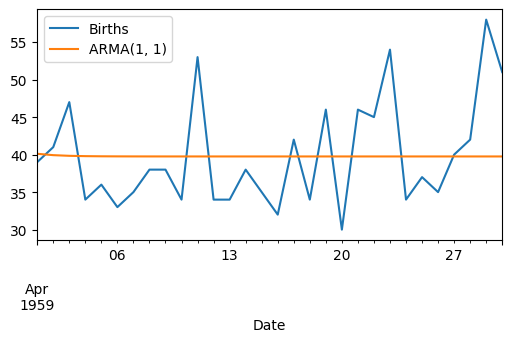

In [ ]:
# we can see that applying the ARMA(1, 1) we are just predicting the mean of the test set, 
# since there is not trend or seasonality in the data, and the model is not able to capture 
# any other pattern
test["Births"].plot(figsize=(6, 3), legend=True);
predictions.plot(legend=True);
print(test["Births"].mean(), predictions.mean())